# 04 - Model Benchmark Sweep

Trains every configured model on the best lookback window selected in notebook 03 and writes the top model back to `debug_exports`.

In [1]:
import os
import json
import sys
from pathlib import Path

# Force CPU-only (disable CUDA/GPUs for TensorFlow/XLA and reduce noisy GPU init logs)
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("OMP_NUM_THREADS", "1")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from IPython.display import display

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "src").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))
load_dotenv(str(ROOT / ".env"), override=False)

from src.features.feature_catalog import get_feature_catalog
from src.models.evaluate import evaluate_forecast, per_horizon_metrics
from src.models.model_configs import MODEL_CONFIGS
from src.models.train import train_model
from src.utils.mongo_client import get_database

sns.set_theme(style="whitegrid")

ARTIFACTS_DIR = ROOT / "debug_exports"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

SIMPLE_MODEL_TYPES = {"lgbm", "xgb", "cat", "rf", "extra", "gbr"}
horizon = 72
# Default evaluation window (days). Set to 80 per request to benchmark on an 80-day window.
eval_window_days = 80
# If you want to use the saved best window from the time-window study, set use_saved_window = True
use_saved_window = False
best_window_path = ARTIFACTS_DIR / "best_window_days.json"
if use_saved_window and best_window_path.exists():
    with open(best_window_path, "r", encoding="utf-8") as handle:
        payload = json.load(handle)
    eval_window_days = int(payload.get("best_window_days", eval_window_days))
best_window_days = eval_window_days


def build_window_frame(frame: pd.DataFrame, days: int) -> pd.DataFrame:
    latest_timestamp = frame["timestamp"].max()
    window_start = latest_timestamp - pd.Timedelta(days=days)
    return frame.loc[frame["timestamp"] >= window_start].sort_values("timestamp").reset_index(drop=True)


def prepare_training_matrices(window_frame: pd.DataFrame, feature_cols: list[str]):
    if len(window_frame) <= horizon:
        return None, None, None

    target = window_frame["european_aqi"].astype(float)
    feature_frame = window_frame[feature_cols].apply(pd.to_numeric, errors="coerce").ffill().fillna(0.0)
    feature_frame = feature_frame.loc[:, feature_frame.nunique(dropna=True) > 1].copy()
    if feature_frame.empty or len(feature_frame) <= horizon:
        return None, None, None

    y = pd.DataFrame([target.iloc[index : index + horizon].values for index in range(len(target) - horizon)])
    x = feature_frame.iloc[: len(y)].copy()
    if x.empty:
        return None, None, None

    return x, y, list(x.columns)


db = get_database()
collection = db["aqi_features_rawalpindi"]
data = pd.DataFrame(list(collection.find()))

if data.empty:
    raise ValueError("aqi_features_rawalpindi is empty")

if "_id" in data.columns:
    data = data.drop(columns=["_id"])

data["timestamp"] = pd.to_datetime(data["timestamp"], utc=True, errors="coerce")
data = data.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

feature_cols = [column for column in get_feature_catalog() if column in data.columns]
window_frame = build_window_frame(data, best_window_days)
x, y, used_features = prepare_training_matrices(window_frame, feature_cols)

if x is None or y is None:
    raise ValueError("Unable to prepare benchmark matrices for the selected window")

2026-05-30 14:20:15.583836: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780132815.602289   81437 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780132815.607200   81437 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780132815.620848   81437 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780132815.620865   81437 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780132815.620866   81437 computation_placer.cc:177] computation placer alr

Running benchmark for lightgbm...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001268 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13279
[LightGBM] [Info] Number of data points in the train set: 445, number of used features: 186
[LightGBM] [Info] Start training from score 34.698876
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

...

Finished random_forest: rmse=12.8983
Running benchmark for extra_trees...


Finished extra_trees: rmse=0.9312
Running benchmark for gradient_boosting...


Finished gradient_boosting: rmse=20.5637


,model,type,window_days,rows_after_prep,features_used,rmse,mae,r2,rmse_24h,rmse_48h,rmse_72h
0,lightgbm,lgbm,80,495,186,3.069094,2.041347,0.000000,3.239549,2.569997,1.873426
1,random_forest,rf,80,495,186,12.898280,4.970091,0.333333,2.374081,0.239968,0.227962
2,extra_trees,extra,80,495,186,0.931230,0.513300,0.083333,0.444316,0.113842,0.060000
3,gradient_boosting,gbr,80,495,186,20.563707,9.480220,0.000000,9.679518,0.482420,0.235320


Saved /home/mwasifshakeel/Videos/pearls-aqi-predictor/debug_exports/model_benchmark_metrics.csv
Best model: extra_trees
Best tree model: extra_trees


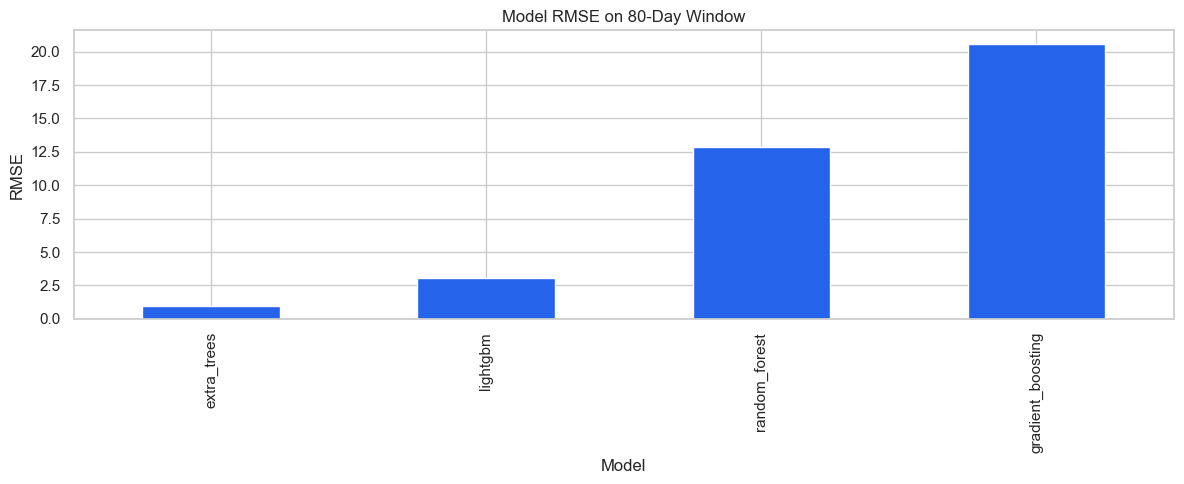

In [2]:
results = []
benchmark_model_names = {"lightgbm", "random_forest", "gradient_boosting", "extra_trees"}
benchmark_models = [config for config in MODEL_CONFIGS if config.name in benchmark_model_names]
for config in benchmark_models:
    print(f"Running benchmark for {config.name}...")
    try:
        model, preds, y_true = train_model(config, x, y, horizon=horizon)
        metrics = evaluate_forecast(y_true, preds)
        metrics.update(per_horizon_metrics(y_true, preds))
        results.append(
            {
                "model": config.name,
                "type": config.type,
                "window_days": best_window_days,
                "rows_after_prep": len(x),
                "features_used": len(used_features),
                **metrics,
            }
        )
        print(f"Finished {config.name}: rmse={metrics['rmse']:.4f}")
    except Exception as exc:
        # Ensure result schema is consistent so subsequent DataFrame ops don't fail
        print(f"Model {config.name} failed: {exc}")
        results.append(
            {
                "model": config.name,
                "type": config.type,
                "window_days": best_window_days,
                "rows_after_prep": len(x),
                "features_used": len(used_features),
                "rmse": float("nan"),
                "mae": float("nan"),
                "r2": float("nan"),
                "error": str(exc),
            }
        )

results_df = pd.DataFrame(results)
results_path = ARTIFACTS_DIR / "model_benchmark_metrics.csv"
results_df.to_csv(results_path, index=False)

valid_results = results_df.dropna(subset=["rmse"]).copy()
if valid_results.empty:
    raise ValueError("All benchmark runs failed")

valid_results = valid_results.sort_values(["rmse", "model"], na_position="last").reset_index(drop=True)
best_row = valid_results.iloc[0]
best_model_name = str(best_row["model"])
best_tree_results = valid_results[valid_results["model"].isin(benchmark_model_names)].copy()
if not best_tree_results.empty:
    best_tree_results = best_tree_results.sort_values(["rmse", "model"], na_position="last").reset_index(drop=True)
best_tree_model_name = str(best_tree_results.iloc[0]["model"]) if not best_tree_results.empty else best_model_name

with open(ARTIFACTS_DIR / "best_model_name.txt", "w", encoding="utf-8") as handle:
    handle.write(best_model_name)

with open(ARTIFACTS_DIR / "best_tree_model_name.txt", "w", encoding="utf-8") as handle:
    handle.write(best_tree_model_name)

with open(ARTIFACTS_DIR / "best_model_metadata.json", "w", encoding="utf-8") as handle:
    json.dump(
        {
            "best_model_name": best_model_name,
            "best_model_type": str(best_row["type"]),
            "best_window_days": best_window_days,
            "rmse": float(best_row["rmse"]),
            "mae": float(best_row["mae"]),
            "r2": float(best_row["r2"]),
            "rows_after_prep": int(best_row["rows_after_prep"]),
            "features_used": int(best_row["features_used"]),
        },
        handle,
        indent=2,
    )

display(results_df)

fig, ax = plt.subplots(figsize=(12, 5))
valid_results.sort_values("rmse").plot(
    kind="bar",
    x="model",
    y="rmse",
    ax=ax,
    color="#2563eb",
    legend=False,
)
ax.set_title(f"Model RMSE on {best_window_days}-Day Window")
ax.set_xlabel("Model")
ax.set_ylabel("RMSE")
plt.tight_layout()

print(f"Saved {results_path}")
print(f"Best model: {best_model_name}")
print(f"Best tree model: {best_tree_model_name}")